# 02 · Resultados — Pronóstico de demanda para reposición inteligente

Este notebook es el **resumen ejecutivo** del proyecto: qué se construyó, qué evidencia de los datos motivó cada decisión, y cómo interpretar los resultados del modelo. No contiene lógica de negocio: todo el trabajo pesado vive en el pipeline (`src/`) y aquí solo se **leen los artefactos** que éste produce.

## Qué se construyó

Un pipeline de pronóstico de demanda a **14 días** para las **480 series tienda × categoría**, con tres etapas ejecutables:

| Comando | Qué hace | Artefactos |
|---|---|---|
| `uv run retail-backtest` | Valida el modelo contra 2 baselines con walk-forward (6 cortes) | `outputs/backtests/<run>/` |
| `uv run retail-train` | Entrena el modelo final con toda la historia y lo serializa | `outputs/models/<run>/` |
| `uv run retail-predict` | Pronostica los próximos 14 días con el último modelo | `outputs/forecasts/<run>/` |

**Los tres competidores del backtest** (predicen exactamente las mismas celdas):

- `gradient_boosting` — el campeón: un `HistGradientBoostingRegressor` global (pérdida Poisson) con rezagos de demanda ≥ 14 días, calendario del día objetivo y atributos de tienda.
- `sistema_actual` — la señal del sistema de reposición vigente (`replenishment_signal`) reescalada a unidades. Ventaja informacional: usa la señal emitida *el mismo día* que pronostica.
- `naive_estacional` — promedio del mismo día de la semana, 2–4 semanas atrás. El piso mínimo a vencer.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, viz
from src.artifacts import latest_run_dir
from src.data import load_calendar, load_stores, load_transactions
from src.metrics import evaluate

warnings.filterwarnings("ignore")
viz.apply_style()

tx, stores, cal = load_transactions(), load_stores(), load_calendar()

run_dir = latest_run_dir("backtests")
preds = pd.read_csv(run_dir / "predictions.csv", parse_dates=["date"])
metrics = pd.read_csv(run_dir / "metrics.csv")
print(f"Backtest leído de: {run_dir}")
print(f"{len(preds):,} predicciones | modelos: {sorted(preds.modelo.unique())}")

# Estética fija de los 4 actores en todo el notebook
MODEL_COLORS = {
    "real": viz.INK,
    "gradient_boosting": "#2a78d6",
    "sistema_actual": "#e34948",
    "naive_estacional": "#eda100",
}
MODEL_LABELS = {
    "gradient_boosting": "Modelo (gradient boosting)",
    "sistema_actual": "Sistema actual",
    "naive_estacional": "Naïve estacional",
}

# Solo celdas con real observado: los 3 modelos se comparan sobre lo mismo
scored = preds[preds.y_true.notna()].merge(stores[["store_id", "store_format"]], on="store_id")

Backtest leído de: /Users/owner/Downloads/Prueba_Tecnica_DS/outputs/backtests/20260705_030909
120,960 predicciones | modelos: ['gradient_boosting', 'naive_estacional', 'sistema_actual']


---
## 1 · Los datos detrás de cada decisión de diseño

### 1.1 El calendario mueve la demanda (y es conocido de antemano)

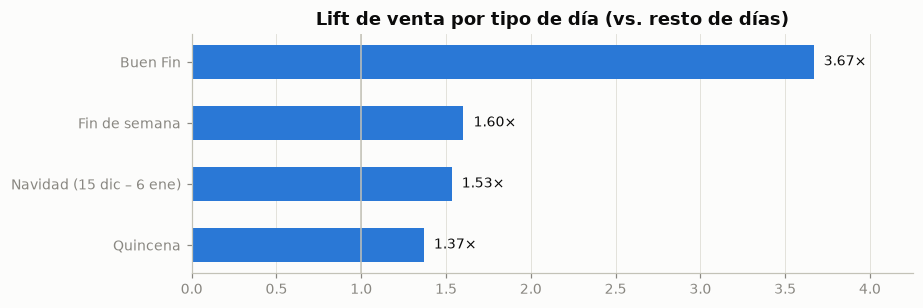

In [2]:
txc = tx.merge(cal, on="date")

def lift(mask):
    return txc[mask].amount_total.mean() / txc[~mask].amount_total.mean()

lifts = pd.Series({
    "Buen Fin": lift(txc.is_buen_fin),
    "Fin de semana": lift(txc.is_weekend),
    "Navidad (15 dic – 6 ene)": lift(txc.is_navidad_season),
    "Quincena": lift(txc.is_payday),
}).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 2.9))
bars = ax.barh(lifts.index, lifts.values, color=viz.ACCENT, height=0.55)
ax.axvline(1, color=viz.BASELINE, lw=1)
for b, v in zip(bars, lifts.values):
    ax.text(v + 0.06, b.get_y() + b.get_height() / 2, f"{v:.2f}×",
            va="center", fontsize=9, color=viz.INK)
ax.set_xlim(0, lifts.max() * 1.16)
ax.set_title("Lift de venta por tipo de día (vs. resto de días)")
ax.grid(axis="y", visible=False)
plt.tight_layout()

> **Decisión →** los flags del calendario (día de semana, quincena, eventos) entran como *features* del día objetivo: son los drivers más fuertes de la demanda y se conocen con anticipación ilimitada.

### 1.2 El sistema de reposición actual reacciona en lugar de anticipar

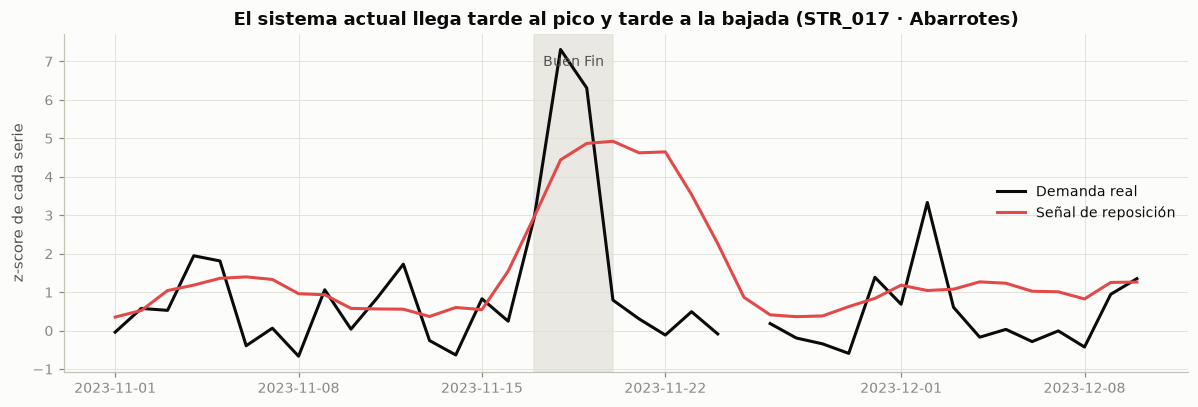

In [3]:
txs = tx.sort_values(["store_id", "category", "date"]).reset_index(drop=True)
g = txs.groupby(["store_id", "category"], observed=True)
txs["units_z"] = (txs.units_sold - g.units_sold.transform("mean")) / g.units_sold.transform("std")
txs["rs_z"] = (txs.replenishment_signal - g.replenishment_signal.transform("mean")) \
              / g.replenishment_signal.transform("std")

s = txs[(txs.store_id == "STR_017") & (txs.category == "Abarrotes")]
win = s[(s.date >= "2023-11-01") & (s.date <= "2023-12-10")]

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axvspan(pd.Timestamp("2023-11-17"), pd.Timestamp("2023-11-20"),
           color=viz.GRID, alpha=0.7, zorder=0)
ax.plot(win.date, win.units_z, color=MODEL_COLORS["real"], lw=2, label="Demanda real")
ax.plot(win.date, win.rs_z, color=MODEL_COLORS["sistema_actual"], label="Señal de reposición")
ax.text(pd.Timestamp("2023-11-18 12:00"), ax.get_ylim()[1] * 0.93, "Buen Fin",
        ha="center", va="top", fontsize=9, color=viz.INK_SECONDARY)
ax.legend(loc="center right")
ax.set_title("El sistema actual llega tarde al pico y tarde a la bajada (STR_017 · Abarrotes)")
ax.set_ylabel("z-score de cada serie")
plt.tight_layout()

> **Decisión →** la señal del sistema actual es ~una media móvil de la demanda pasada: sub-surte ~34% durante el pico y sobre-surte ~2.3× después. Por eso el producto es un **pronóstico predictivo**, la señal queda **excluida como feature** (sería fuga de información: se deriva de la demanda) y se usa como **baseline a vencer**.

### 1.3 Las tiendas son muy heterogéneas

Dispersión: la tienda más grande vende 7.5× lo de la menor


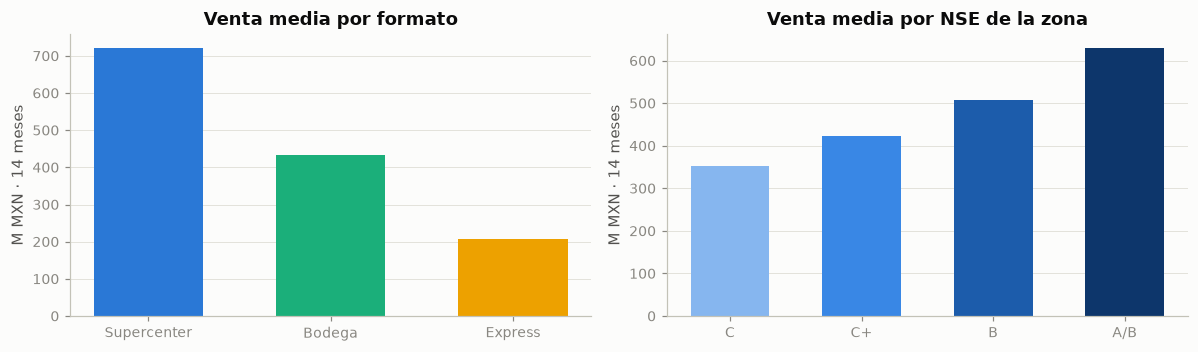

In [4]:
rev = tx.groupby("store_id").amount_total.sum().rename("rev")
stx = stores.merge(rev, on="store_id")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
f = stx.groupby("store_format", observed=True).rev.mean() / 1e6
axes[0].bar(f.index.astype(str), f.values, width=0.6,
            color=[viz.FORMAT_COLORS[x] for x in f.index])
axes[0].set_title("Venta media por formato")
axes[0].set_ylabel("M MXN · 14 meses")

nse = stx.groupby("socioeconomic_level", observed=True).rev.mean() / 1e6
axes[1].bar(nse.index.astype(str), nse.values, width=0.6,
            color=["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
axes[1].set_title("Venta media por NSE de la zona")
axes[1].set_ylabel("M MXN · 14 meses")
for ax in axes:
    ax.grid(axis="x", visible=False)
plt.tight_layout()

print(f"Dispersión: la tienda más grande vende {stx.rev.max() / stx.rev.min():.1f}× lo de la menor")

> **Decisión →** un **modelo global** (uno para las 480 series, no 480 modelos): aprende los patrones compartidos una sola vez y los ajusta por serie con los atributos de tienda (formato, tamaño, NSE, región) y los rezagos propios de cada serie.

Y la regla que gobierna todo el diseño de features: **ningún dato de demanda posterior a t − 14** entra al pronóstico del día *t* (rezagos de 14/21/28 días, múltiplos de 7). Cada predicción del backtest es un pronóstico *honesto* emitido 14 días antes — garantizado además por una prueba automática (`tests/test_features.py`).

---
## 2 · Resultados del backtest

**Cómo leer las métricas:** `WAPE` = error total como fracción de las unidades reales (0.25 → "me equivoco 25 de cada 100 unidades"; menor es mejor y es la métrica que decide). `MAE` = unidades de error promedio por tienda-categoría-día. `bias` = signo del error neto: negativo → sub-pronóstico (quiebre de stock), positivo → sobre-pronóstico (merma). Compara siempre **modelos dentro del mismo segmento**, nunca segmentos entre sí.

WAPE por segmento y modelo:
          gradient_boosting  sistema_actual  naive_estacional
segmento                                                     
total                 0.326           0.325             0.416
pico                  0.459           0.369             0.519
normal                0.253           0.301             0.360 



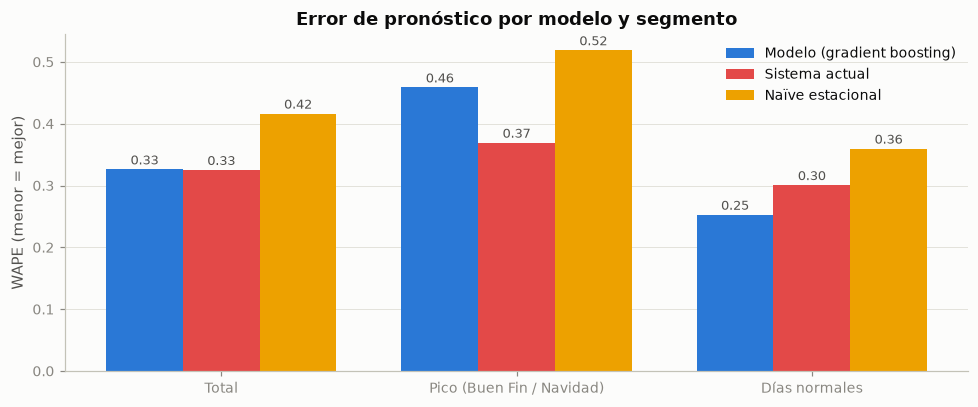

In [5]:
tabla = metrics.pivot(index="segmento", columns="modelo", values="wape") \
               .loc[["total", "pico", "normal"],
                    ["gradient_boosting", "sistema_actual", "naive_estacional"]]
tabla.columns.name = None
print("WAPE por segmento y modelo:")
print(tabla.round(3).to_string(), "\n")

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(3)
ancho = 0.26
for i, modelo in enumerate(tabla.columns):
    barras = ax.bar(x + (i - 1) * ancho, tabla[modelo], ancho,
                    color=MODEL_COLORS[modelo], label=MODEL_LABELS[modelo])
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.008,
                f"{b.get_height():.2f}", ha="center", fontsize=8.5, color=viz.INK_SECONDARY)
ax.set_xticks(x)
ax.set_xticklabels(["Total", "Pico (Buen Fin / Navidad)", "Días normales"])
ax.set_ylabel("WAPE (menor = mejor)")
ax.set_title("Error de pronóstico por modelo y segmento")
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
plt.tight_layout()

In [6]:
por_fold = evaluate(scored, by=["fold_origin", "modelo"]) \
    .pivot(index="fold_origin", columns="modelo", values="wape") \
    [["gradient_boosting", "sistema_actual", "naive_estacional"]].round(3)
por_fold.columns.name = None
etiquetas = {"2023-07-03": "jul (normal)", "2023-09-04": "sep (normal)",
             "2023-11-06": "nov — BUEN FIN", "2023-12-11": "dic — NAVIDAD",
             "2024-01-15": "ene (normal)", "2024-02-12": "feb (normal)"}
por_fold.index = [etiquetas[i] for i in por_fold.index]
print("WAPE por corte del walk-forward (gana el menor por fila):")
por_fold

WAPE por corte del walk-forward (gana el menor por fila):


,gradient_boosting,sistema_actual,naive_estacional
jul (normal),0.236,0.311,0.268
sep (normal),0.258,0.301,0.284
nov — BUEN FIN,0.450,0.368,0.508
dic — NAVIDAD,0.350,0.333,0.400
ene (normal),0.274,0.293,0.743
feb (normal),0.241,0.291,0.270


**Lectura de los resultados:**

1. **En días normales el modelo gana siempre**: WAPE 0.253 vs 0.301 del sistema actual (−5 pp) y 0.360 del naïve, con sesgo **+0.6%** (calibración casi perfecta). Gana los 4 folds normales.
2. **El fold de enero expone la falla estructural del enfoque reactivo**: el naïve colapsa a 0.74 porque sus rezagos arrastran el pico navideño hacia adelante — la misma "cruda post-pico" del sistema actual. El modelo pasa limpio (0.274) porque el calendario le dice que la fiesta terminó.
3. **En los picos nadie gana de verdad.** El Buen Fin del backtest es el *primero que existe en los datos* (la historia empieza en enero 2023): ningún método puede aprender un evento jamás observado, y el modelo queda con sesgo −0.39. El sistema actual luce mejor (0.369) solo por su ventaja informacional — reacciona *dentro* del pico con la señal del mismo día — y aun así sub-surte 23%.
4. La fila `total` (0.326 vs 0.325) es un promedio que mezcla estas dos historias opuestas; **leerla sola llevaría a la conclusión equivocada**.

---
## 3 · Las predicciones vistas en sus agrupaciones

Cada gráfica agrega las predicciones de las mismas celdas evaluadas: línea negra = demanda real; colores = lo que cada modelo pronosticó **14 días antes**. Solo existen valores en las 6 ventanas de prueba del walk-forward (los huecos entre ventanas son esperados).

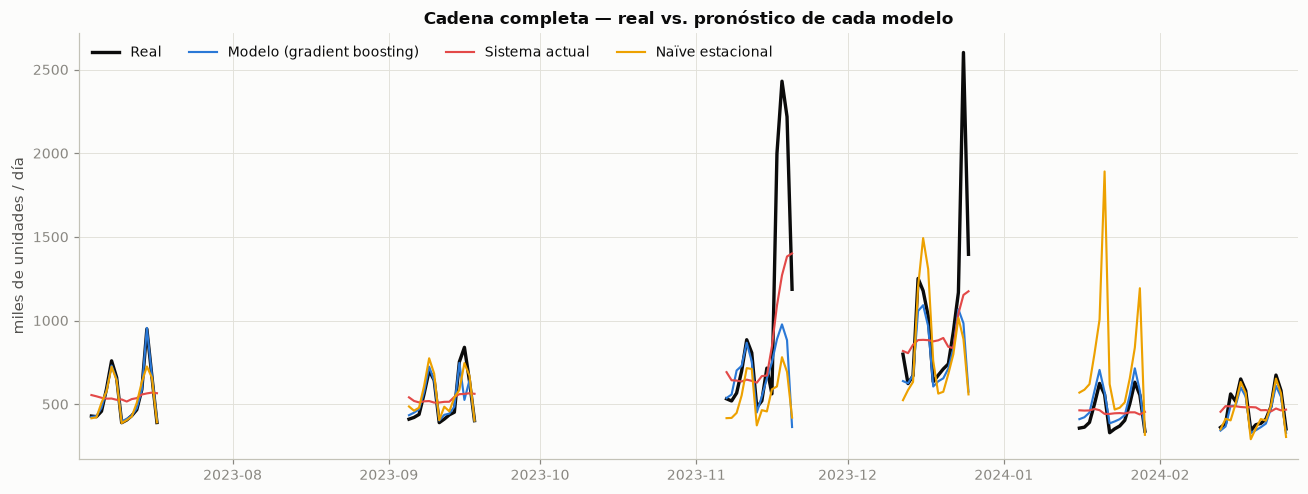

In [7]:
FECHAS = pd.date_range(scored.date.min(), scored.date.max(), freq="D")

def plot_real_vs_modelos(ax, df, titulo, unidades="miles de unidades / día"):
    real = df[df.modelo == "gradient_boosting"].groupby("date").y_true.sum() / 1e3
    ax.plot(real.reindex(FECHAS).index, real.reindex(FECHAS).values,
            color=MODEL_COLORS["real"], lw=2.2, label="Real")
    for modelo in ["gradient_boosting", "sistema_actual", "naive_estacional"]:
        serie = df[df.modelo == modelo].groupby("date").y_pred.sum() / 1e3
        ax.plot(serie.reindex(FECHAS).index, serie.reindex(FECHAS).values,
                color=MODEL_COLORS[modelo], lw=1.4, label=MODEL_LABELS[modelo])
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel(unidades)
    ax.margins(x=0.01)

fig, ax = plt.subplots(figsize=(12, 4.6))
plot_real_vs_modelos(ax, scored, "Cadena completa — real vs. pronóstico de cada modelo")
ax.legend(loc="upper left", ncol=4)
plt.tight_layout()

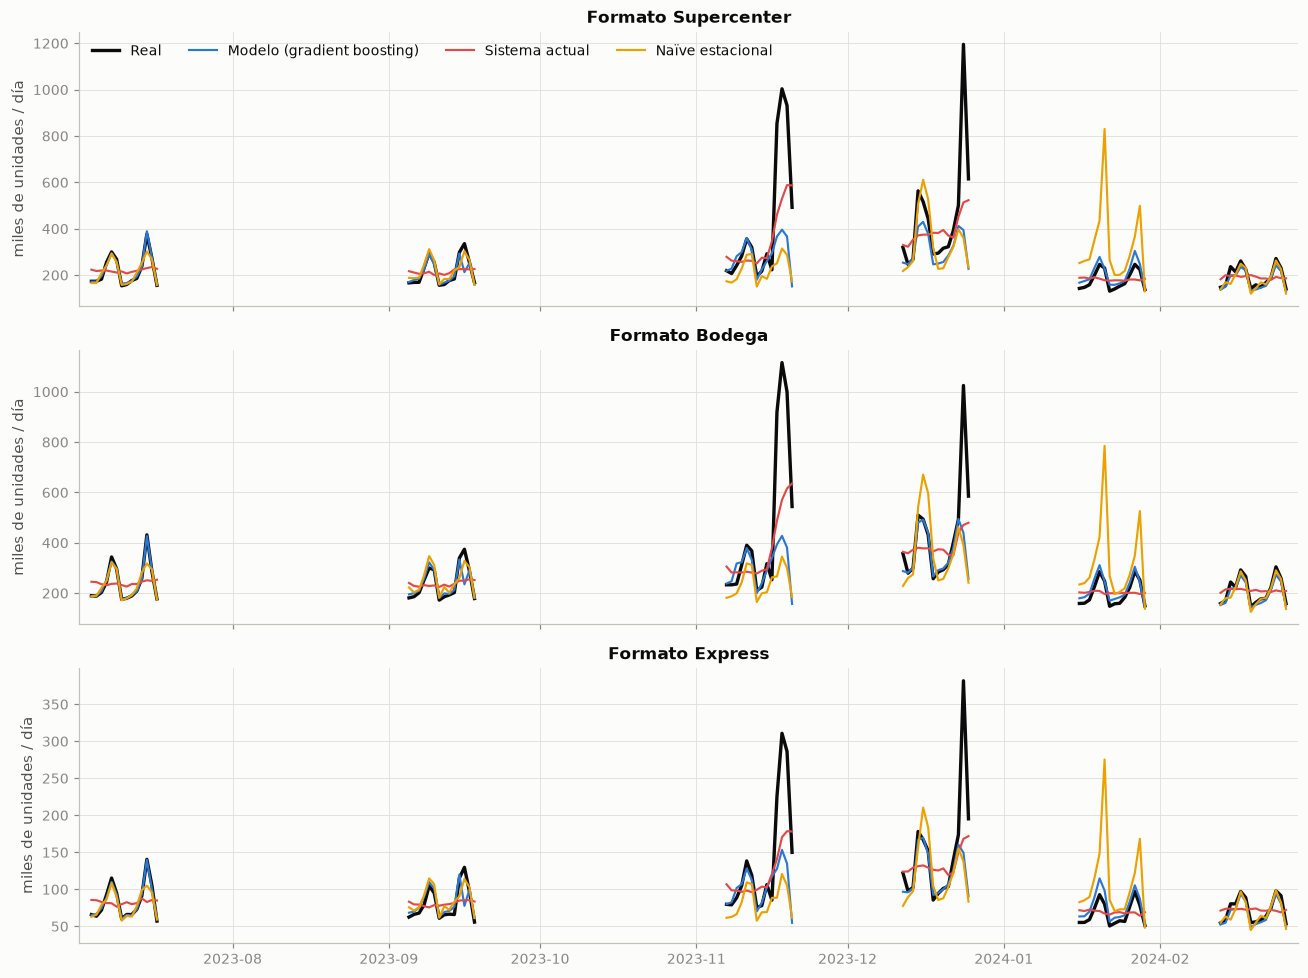

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, fmt in zip(axes, config.STORE_FORMATS):
    plot_real_vs_modelos(ax, scored[scored.store_format == fmt], f"Formato {fmt}")
axes[0].legend(loc="upper left", ncol=4)
plt.tight_layout()

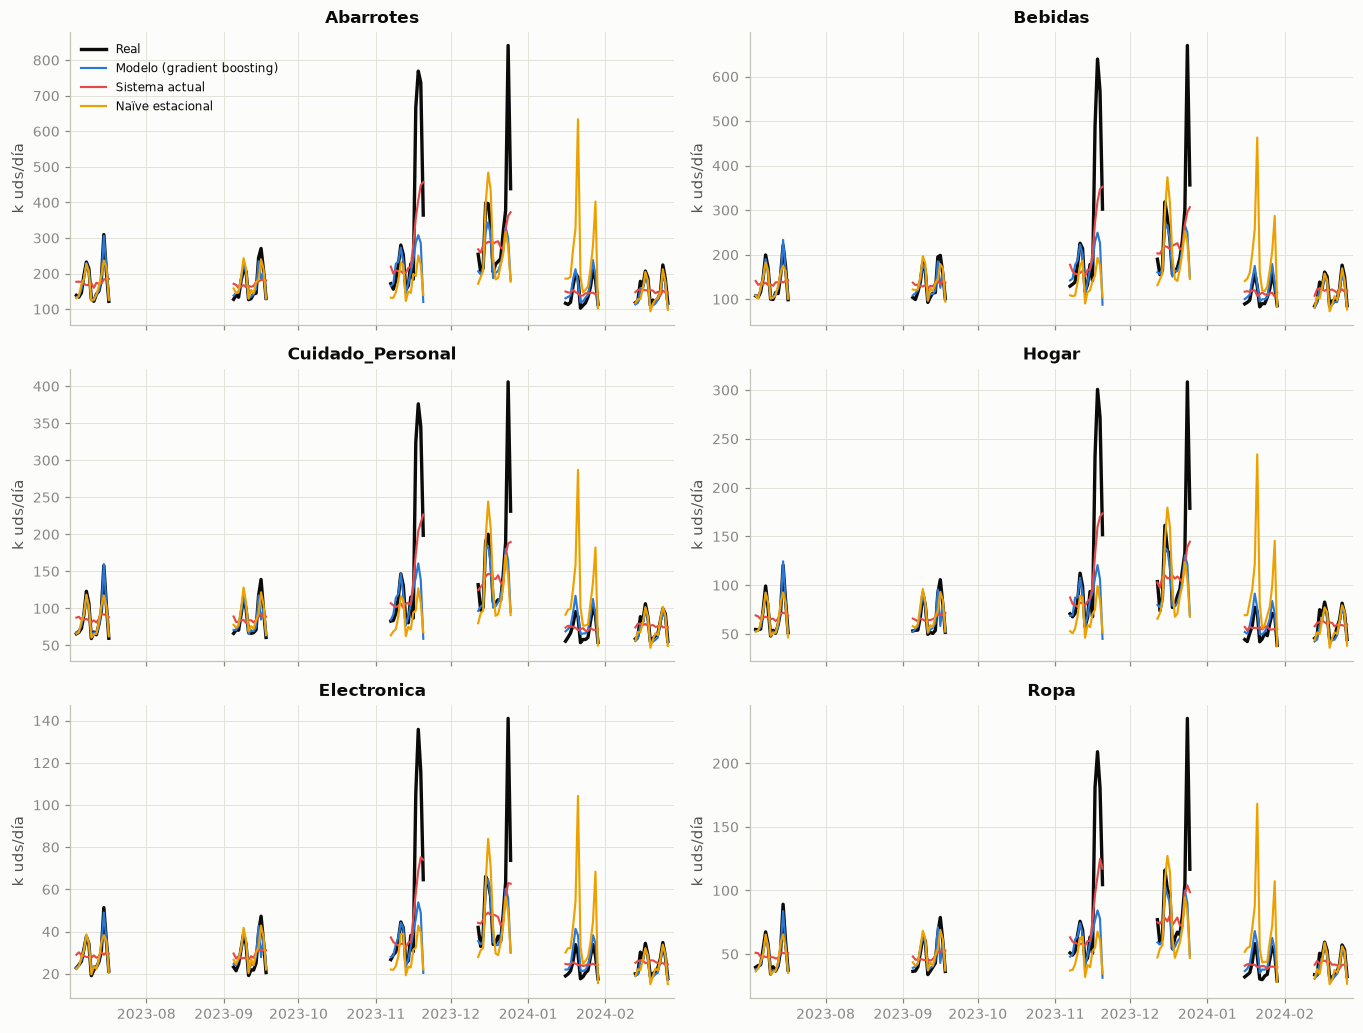

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(12.5, 9.5), sharex=True)
for ax, cat in zip(axes.ravel(), config.CATEGORIES):
    plot_real_vs_modelos(ax, scored[scored.category == cat], cat, unidades="k uds/día")
axes[0, 0].legend(loc="upper left", fontsize=8)
plt.tight_layout()

### 3.1 ¿Y en números? WAPE por formato y por categoría

Se calcula sobre **días normales**: es la comparación justa de lo desplegable (en picos ningún método vio el evento — sección 2 — y mezclarlos diluiría ambas historias).

WAPE por formato (días normales):
modelo        gradient_boosting  sistema_actual  naive_estacional
store_format                                                     
Supercenter               0.252           0.300             0.375
Bodega                    0.253           0.301             0.348
Express                   0.254           0.301             0.354 

WAPE por categoría (días normales):
modelo            gradient_boosting  sistema_actual  naive_estacional
category                                                             
Abarrotes                     0.252           0.303             0.361
Bebidas                       0.247           0.301             0.357
Cuidado_Personal              0.260           0.301             0.362
Hogar                         0.254           0.296             0.358
Electronica                   0.255           0.301             0.363
Ropa                          0.255           0.299             0.359


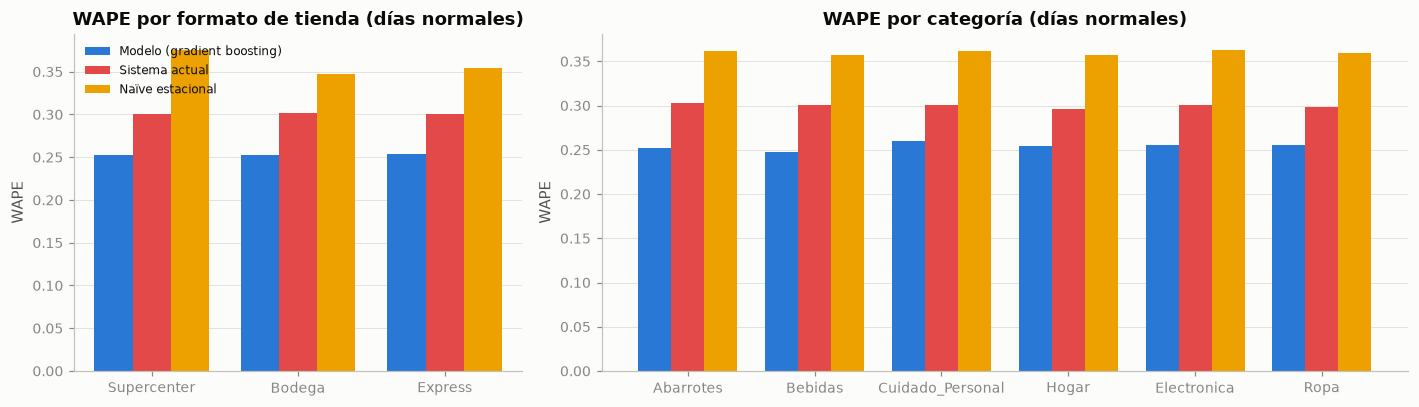

In [10]:
def barras_wape(ax, tabla, titulo):
    x = np.arange(len(tabla))
    ancho = 0.26
    for i, modelo in enumerate(tabla.columns):
        ax.bar(x + (i - 1) * ancho, tabla[modelo], ancho,
               color=MODEL_COLORS[modelo], label=MODEL_LABELS[modelo])
    ax.set_xticks(x)
    ax.set_xticklabels(tabla.index, fontsize=9)
    ax.set_ylabel("WAPE")
    ax.set_title(titulo)
    ax.grid(axis="x", visible=False)

normales = scored[scored.segmento == "normal"]
por_formato = evaluate(normales, by=["modelo", "store_format"]) \
    .pivot(index="store_format", columns="modelo", values="wape") \
    .loc[config.STORE_FORMATS, ["gradient_boosting", "sistema_actual", "naive_estacional"]]
por_categoria = evaluate(normales, by=["modelo", "category"]) \
    .pivot(index="category", columns="modelo", values="wape") \
    .loc[config.CATEGORIES, ["gradient_boosting", "sistema_actual", "naive_estacional"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 1.8]})
barras_wape(axes[0], por_formato, "WAPE por formato de tienda (días normales)")
barras_wape(axes[1], por_categoria, "WAPE por categoría (días normales)")
axes[0].legend(fontsize=8)
plt.tight_layout()

print("WAPE por formato (días normales):")
print(por_formato.round(3).to_string(), "\n")
print("WAPE por categoría (días normales):")
print(por_categoria.round(3).to_string())

---
## 4 · Conclusiones

**Lo que el modelo ya hace mejor que el sistema vigente:**

- En el **85% de los días del año** (segmento normal) pronostica con WAPE 0.253 vs 0.301 del sistema actual, **sin sesgo** (+0.6%) — es decir, reduce simultáneamente quiebres y merma, y lo hace **14 días antes**, no el mismo día.
- La mejora es **consistente en todas las agrupaciones**: gana en los 3 formatos de tienda y en las 6 categorías (ver 3.1), no depende de un nicho.
- Evita la "cruda post-pico": tras Navidad, el sistema actual sigue pidiendo >2× lo necesario durante días; el modelo vuelve a nivel normal de inmediato (fold de enero: 0.274 vs naïve 0.743).

**El límite honesto y su solución de negocio:**

- Con **un solo año de historia**, los eventos anuales (Buen Fin, Navidad) aparecen por primera vez justo cuando hay que pronosticarlos: ahí ningún método aprende y el modelo sub-estima ~39%. No es un problema de algoritmo sino de dato.
- Camino inmediato: **overlay de uplift planificado** — el Buen Fin 2023 ya está medido (3.7× la venta normal); ese factor se aplica sobre el pronóstico base del Buen Fin 2024 como regla de negocio versionada en el pipeline.
- Camino estructural: al acumular el **segundo año de historia**, el evento se vuelve aprendible y el overlay se retira.

**Traducción a negocio:** en picos, el sistema actual sub-surte 23% *aun reaccionando el mismo día*. Los 4 días del Buen Fin venden ~3.7× un día normal (~370 M MXN/día de cadena): cada punto de quiebre evitado en esos días vale ~15 M MXN de venta protegida. El pronóstico predictivo + uplift planificado ataca exactamente ese hueco, con validación walk-forward reproducible (`uv run retail-backtest`) como evidencia.